# MPRAlm barcode variation

In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr
pl.Config.set_fmt_str_lengths(50)

polars.config.Config

In [28]:
mpralm = pl.read_ipc("../results/HepG2_outputs/mpralm/toptable_all_HepG2.feather", memory_map=False)
mpralm_bc = pl.read_ipc("../results/HepG2_outputs/mpralm_bc/toptable_all_HepG2.feather", memory_map=False)
both = mpralm.join(mpralm_bc, on="variant_id")

In [29]:
both = both.select( 
    pl.all().map_alias(lambda col_name: col_name.replace('right', 'bc'))
)

/tmp/ipykernel_3292310/3910053613.py:2: DeprecationWarning: `map_alias` is deprecated. It has been moved to `name.map`.
  pl.all().map_alias(lambda col_name: col_name.replace('right', 'bc'))


In [30]:
# just a check how many sequences have a very small logFC when using bc MPRAlm and a higher logFC with normal MPRAlm
both.filter(((pl.col("logFC_bc") < 0.05) & (pl.col("logFC_bc") > - 0.05)) & (pl.col("logFC") > 0.5)).height

18

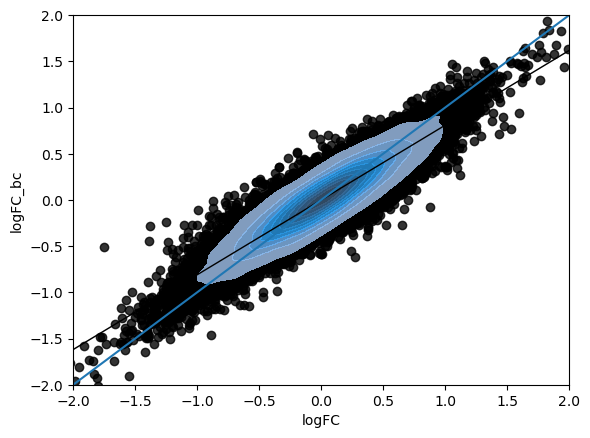

In [31]:
fig, ax = plt.subplots()
ax.set_xlim([-2,2])
ax.set_ylim([-2,2])
sns.regplot(both, x="logFC", y="logFC_bc", color="k", ax=ax, line_kws={"linewidth":1})
sns.kdeplot(both, x="logFC", y="logFC_bc", fill=True, alpha=0.8, ax=ax)
plt.plot
plt.plot(range(-2,3), range(-2,3))



In [32]:
# calculate correlation
both.select(pl.corr("logFC_bc", "logFC"))

logFC_bc
f64
0.899279
